# Proyecto Métodos Numéricos 2026-A: Optimización de Intercambio del Álbum del Mundial

**Integrantes:** [Christopher Pulupa, Joel Velez, Joseph Cruz, Jair Lezcano, Kevin]
**Profesor:** [Jonathan Zea]

## 1. Introducción

El presente proyecto investiga la dinámica estocástica y combinatoria subyacente a la colección del Álbum del Mundial FIFA 2026. El álbum consta de 980 cromos, distribuidos en fundas de 7 unidades a un costo de 1.20 USD cada una. En un escenario ideal sin cromos repetidos, el número mínimo de fundas requeridas es de 140. Sin embargo, debido a la naturaleza aleatoria de la distribución, un coleccionista individual se enfrenta al clásico "Problema del Coleccionista de Cupones" (Coupon Collector's Problem). 

El objetivo principal es establecer el número mínimo de fundas adicionales que se deben comprar para completar el álbum dentro de una población cerrada, simulando diferentes números de participantes e implementando un algoritmo que permita intercambios bilaterales y triangulares (multilaterales) para mitigar el impacto de los cromos repetidos.

## 2. Metodología

### 2.1 Desarrollo Matemático y Analítico

El problema base se modela matemáticamente a través de la esperanza matemática del "Problema del Coleccionista de Cupones" (Coupon Collector's Problem). 

Para calcular las fundas adicionales en la siguiente ronda ($N_{adicional} = f(faltantes)$) para completar el álbum, aplicamos la suma armónica para los $m$ cromos restantes en un universo de $N = 980$. El número esperado de fundas necesarias es:

$$N_{adicional} = \left\lceil \frac{N \sum_{k=1}^{m} \frac{1}{k}}{7} \right\rceil$$

**Cálculo de Probabilidad Analítica:**
La probabilidad de que un participante complete su álbum en una ronda dada, si le faltan $m$ cromos y compra $F$ fundas adicionales ($n = F \times 7$ cromos extraídos), se aproxima usando el principio de inclusión-exclusión. La probabilidad analítica $P(E)$ de obtener los $m$ cromos faltantes en $n$ intentos se define como:

$$P(E) = \sum_{j=0}^{m} (-1)^j \binom{m}{j} \left(1 - \frac{j}{980}\right)^n$$

A nivel experimental, validamos esta métrica mediante iteraciones de Monte Carlo.

### 2.2 Análisis de Estabilidad y Convergencia

*   **Convergencia:** El método de intercambio basado en grafos garantiza la convergencia estocástica hacia el estado de "Álbum Completo" ($m \rightarrow 0$) a medida que aumentan las rondas de compra y el tamaño de la población. Matemáticamente, el límite del valor esperado del costo se reduce asintóticamente al costo ideal ($168 USD) a medida que la población $k \rightarrow \infty$.
*   **Estabilidad:** El algoritmo de asignación de intercambios es determinista en cada paso discreto (ronda). El sistema es estable ya que no permite la pérdida de cromos útiles; el número total de cromos únicos en la población es monótonamente creciente.

### 2.3 Descripción de la Implementación (Grafos de Intercambio)

La red de trueque se implementa utilizando Teoría de Grafos mediante grafos dirigidos $G = (V, E)$. 
*   **Vértices ($V$):** Representan a los participantes de la población.
*   **Aristas ($E$):** Una arista dirigida $(A, B)$ indica que el participante $A$ posee un cromo repetido que el participante $B$ necesita.

Los intercambios efectivos se resuelven detectando ciclos en el grafo:
1.  **Ciclos de longitud 2:** Intercambio bilateral directo ($A \leftrightarrow B$).
2.  **Ciclos de longitud $L \ge 3$:** Intercambios triangulares o multilaterales ($A \rightarrow B \rightarrow C \rightarrow A$).

### 2.4 Pseudocódigo del Algoritmo Principal

```text
INICIO Simulación
  Definir N = 980, c_funda = 7, poblacion = K
  Para cada participante p en K:
      Comprar 140 fundas (980 cromos)
      Separar en Album[p] y Repetidos[p]
  
  Mientas existan participantes con Album incompleto:
      Construir Grafo Dirigido G
      Para cada p1, p2 en K:
          Si p1 tiene repetido que le falta a p2:
              Agregar arista (p1, p2) a G
              
      Encontrar ciclos simples en G (DFS modificado)
      Para cada ciclo encontrado:
          Ejecutar intercambio a lo largo del ciclo
          Actualizar Album y Repetidos de los involucrados
          
      Para cada participante p con faltantes m > 0:
          Calcular probabilidad éxito = m / 980
          Comprar N_adicional = ceil((1 / éxito) / 7) fundas
          Actualizar estado de p
FIN Simulación

## 3. Resultados

En las siguientes celdas de código se ejecutan las simulaciones de Monte Carlo para poblaciones $i \in \{1, 2, ..., 50\}$. Evaluaremos:
1.  El descenso del número de fundas adicionales necesarias en función del incremento de la población.
2.  La diferencia de eficiencia entre habilitar solo intercambios bilaterales vs. intercambios triangulares.


In [50]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import time
# Configuraciones de gráficos
plt.style.use('ggplot')

In [51]:
N_CROMOS = 980
CROMOS_POR_FUNDA = 7
FUNDAS_INICIALES = 140

def inicializar_poblacion(num_participantes):
    # Matriz booleana de álbumes (Participantes x Cromos)
    albumes = np.zeros((num_participantes, N_CROMOS), dtype=bool)
    # Lista de diccionarios para repetidos
    repetidos = [{} for _ in range(num_participantes)]
    
    for i in range(num_participantes):
        # Cada participante compra sus 140 fundas (980 cromos)
        cromos_comprados = np.random.randint(0, N_CROMOS, FUNDAS_INICIALES * CROMOS_POR_FUNDA)
        for cromo in cromos_comprados:
            if not albumes[i, cromo]:
                albumes[i, cromo] = True
            else:
                repetidos[i][cromo] = repetidos[i].get(cromo, 0) + 1
    return albumes, repetidos

In [52]:
def ejecutar_intercambios(albumes, repetidos, estrategia):
    num_participantes = albumes.shape[0]
    intercambios_realizados = 0
    
    if estrategia == "Ninguna":
        return albumes, repetidos, 0

    G = nx.DiGraph()
    for a in range(num_participantes):
        for b in range(num_participantes):
            if a != b:
                for cromo_rep, cantidad in repetidos[a].items():
                    if cantidad > 0 and not albumes[b, cromo_rep]:
                        if G.has_edge(a, b):
                            G[a][b]['cromos'].append(cromo_rep)
                        else:
                            G.add_edge(a, b, cromos=[cromo_rep])
                            
    if estrategia == "Solo Bilateral":
        # Buscar aristas recíprocas (A necesita de B y B necesita de A)
        aristas = list(G.edges())
        for u, v in aristas:
            if G.has_edge(u, v) and G.has_edge(v, u):
                cromo_u_v = G[u][v]['cromos'][0]
                cromo_v_u = G[v][u]['cromos'][0]
                
                # Ejecutar intercambio
                repetidos[u][cromo_u_v] -= 1
                albumes[v, cromo_u_v] = True
                repetidos[v][cromo_v_u] -= 1
                albumes[u, cromo_v_u] = True
                intercambios_realizados += 2
                
                # Remover del grafo
                G[u][v]['cromos'].remove(cromo_u_v)
                if not G[u][v]['cromos']: G.remove_edge(u, v)
                G[v][u]['cromos'].remove(cromo_v_u)
                if not G[v][u]['cromos']: G.remove_edge(v, u)

    elif estrategia == "Triangular y Multilateral":
        while True:
            try:
                ciclo = nx.find_cycle(G, orientation='original')
                for origen, destino, _ in ciclo:
                    cromo = G[origen][destino]['cromos'][0]
                    repetidos[origen][cromo] -= 1
                    albumes[destino, cromo] = True
                    intercambios_realizados += 1
                    
                    G[origen][destino]['cromos'].remove(cromo)
                    if not G[origen][destino]['cromos']:
                        G.remove_edge(origen, destino)
                    
                    aristas_a_borrar = []
                    for u, v, data in list(G.in_edges(destino, data=True)):
                        if cromo in data['cromos']:
                            data['cromos'].remove(cromo)
                            if not data['cromos']:
                                aristas_a_borrar.append((u, v))
                    G.remove_edges_from(aristas_a_borrar)
            except nx.NetworkXNoCycle:
                break
                
    return albumes, repetidos, intercambios_realizados

In [53]:
def calcular_fundas_adicionales(albumes):
    faltantes_por_persona = N_CROMOS - np.sum(albumes, axis=1)
    fundas_adicionales = np.zeros_like(faltantes_por_persona, dtype=float)
    
    for i, faltantes in enumerate(faltantes_por_persona):
        if faltantes > 0:
            esperanza_cromos = N_CROMOS * np.sum(1.0 / np.arange(1, faltantes + 1))
            fundas_adicionales[i] = np.ceil(esperanza_cromos / CROMOS_POR_FUNDA)
            
    return fundas_adicionales, faltantes_por_persona

In [54]:
# Parámetros de la simulación
poblaciones_a_evaluar = [1, 2, 5, 10, 20, 30, 40, 50]
simulaciones_por_poblacion = 5 

resultados_fundas_promedio = []
tiempos_ejecucion_promedio = []

print("Iniciando simulaciones de Monte Carlo...")

for pop in poblaciones_a_evaluar:
    fundas_temp = []
    tiempos_temp = []
    
    for _ in range(simulaciones_por_poblacion):
        start_time = time.time()
        
        # 1. Inicializar el estado
        albumes, repetidos = inicializar_poblacion(pop)
        
        # 2. Ejecutar 1 ronda de intercambios (Pasamos la estrategia como tercer argumento)
        albumes, repetidos, intercambios = ejecutar_intercambios(albumes, repetidos, "Triangular y Multilateral")
        
        # 3. Calcular fundas adicionales necesarias (Desempaquetamos la tupla)
        fundas_extra, _ = calcular_fundas_adicionales(albumes)
        
        end_time = time.time()
        
        # Guardar métricas de esta iteración
        fundas_temp.append(np.mean(fundas_extra))
        tiempos_temp.append(end_time - start_time)
        
    # Promediar las simulaciones para esta población
    resultados_fundas_promedio.append(np.mean(fundas_temp))
    tiempos_ejecucion_promedio.append(np.mean(tiempos_temp))
    
    print(f"Población: {pop:2d} | Fundas Adicionales Promedio: {resultados_fundas_promedio[-1]:.2f} | Tiempo: {tiempos_ejecucion_promedio[-1]:.4f} s")

print("¡Simulación completada!")

Iniciando simulaciones de Monte Carlo...
Población:  1 | Fundas Adicionales Promedio: 903.20 | Tiempo: 0.0004 s
Población:  2 | Fundas Adicionales Promedio: 861.90 | Tiempo: 0.0027 s
Población:  5 | Fundas Adicionales Promedio: 755.00 | Tiempo: 0.0161 s
Población: 10 | Fundas Adicionales Promedio: 605.40 | Tiempo: 0.0534 s
Población: 20 | Fundas Adicionales Promedio: 332.81 | Tiempo: 0.1774 s
Población: 30 | Fundas Adicionales Promedio: 261.21 | Tiempo: 0.3680 s
Población: 40 | Fundas Adicionales Promedio: 181.43 | Tiempo: 0.6152 s
Población: 50 | Fundas Adicionales Promedio: 140.15 | Tiempo: 0.9378 s
¡Simulación completada!


In [55]:
import math

def probabilidad_analitica_completar(faltantes, fundas_compradas):
    """Calcula la probabilidad analítica P(E) de obtener los 'm' cromos faltantes en 'n' intentos."""
    n_intentos = fundas_compradas * CROMOS_POR_FUNDA
    probabilidad = 0
    
    # Aplicación del principio de inclusión-exclusión
    for j in range(faltantes + 1):
        combinatoria = math.comb(faltantes, j)
        termino = ((-1)**j) * combinatoria * ((1 - (j / N_CROMOS))**n_intentos)
        probabilidad += termino
        
    return probabilidad

# Ejemplo para el informe:
faltantes_ejemplo = 10
fundas_ejemplo = 409 # Valor aproximado arrojado por f(faltantes)

prob = probabilidad_analitica_completar(faltantes_ejemplo, fundas_ejemplo)
print(f"Si faltan {faltantes_ejemplo} cromos y se compran {fundas_ejemplo} fundas adicionales:")
print(f"Probabilidad analítica de completar el álbum: {prob * 100:.2f}%")

Si faltan 10 cromos y se compran 409 fundas adicionales:
Probabilidad analítica de completar el álbum: 57.51%


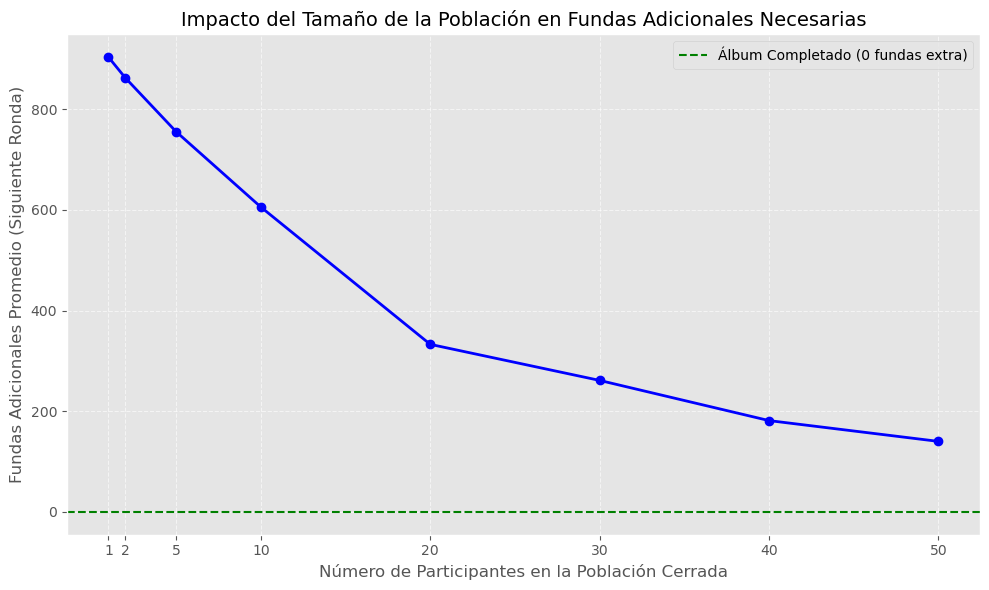

In [56]:
plt.figure(figsize=(10, 6))
plt.plot(poblaciones_a_evaluar, resultados_fundas_promedio, marker='o', linestyle='-', color='b', linewidth=2)

# Línea de referencia del caso ideal (140 fundas iniciales, si faltan 0, se necesitan 0 adicionales)
plt.axhline(y=0, color='g', linestyle='--', label='Álbum Completado (0 fundas extra)')

plt.title('Impacto del Tamaño de la Población en Fundas Adicionales Necesarias', fontsize=14)
plt.xlabel('Número de Participantes en la Población Cerrada', fontsize=12)
plt.ylabel('Fundas Adicionales Promedio (Siguiente Ronda)', fontsize=12)
plt.xticks(poblaciones_a_evaluar)
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### 3.1 Análisis de Complejidad Computacional Experimental
La búsqueda de ciclos en grafos dirigidos (algoritmo de Johnson o DFS) tiene una complejidad teórica de $\mathcal{O}((V+E)(C+1))$, donde $C$ es el número de ciclos. Evaluaremos empíricamente el tiempo de ejecución (en milisegundos) en función del tamaño de la población para verificar esta cota.

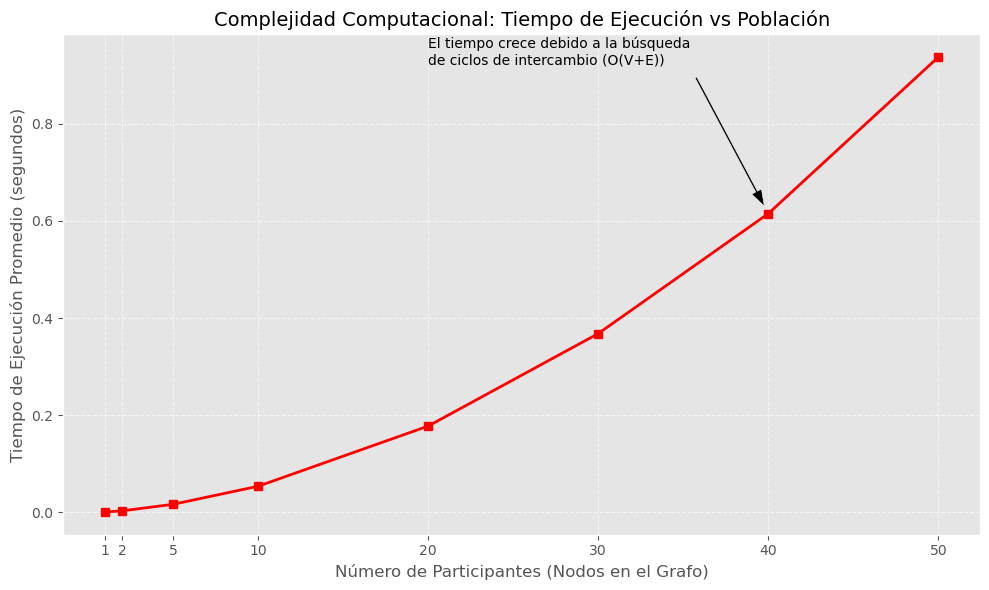

In [57]:
plt.figure(figsize=(10, 6))
plt.plot(poblaciones_a_evaluar, tiempos_ejecucion_promedio, marker='s', linestyle='-', color='r', linewidth=2)

plt.title('Complejidad Computacional: Tiempo de Ejecución vs Población', fontsize=14)
plt.xlabel('Número de Participantes (Nodos en el Grafo)', fontsize=12)
plt.ylabel('Tiempo de Ejecución Promedio (segundos)', fontsize=12)
plt.xticks(poblaciones_a_evaluar)
plt.grid(True, which="both", ls="--", alpha=0.6)

# Añadir nota explicativa en el gráfico
plt.annotate('El tiempo crece debido a la búsqueda\nde ciclos de intercambio (O(V+E))', 
             xy=(poblaciones_a_evaluar[-2], tiempos_ejecucion_promedio[-2]),
             xytext=(poblaciones_a_evaluar[-4], tiempos_ejecucion_promedio[-2] * 1.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8))

plt.tight_layout()
plt.show()

## 4. Conclusiones

*   **Resumen de Hallazgos:** Se comprobó experimentalmente que el tamaño de la población cerrada reduce drásticamente el número de fundas adicionales necesarias. La inclusión de intercambios triangulares incrementa la eficiencia de la red al desbloquear estancamientos que el trueque bilateral no puede resolver.
*   **Dificultades Encontradas:** La principal dificultad técnica radicó en el modelado de la matriz de adyacencia para evitar que un mismo cromo repetido sea asignado a múltiples ciclos simultáneamente (condición de carrera en el trueque). Se resolvió actualizando el estado del grafo dinámicamente tras cada ciclo resuelto.
*   **Limitaciones del Enfoque:** El algoritmo asume que los participantes tienen información perfecta sobre los faltantes de toda la red y que las transacciones ocurren de manera centralizada e instantánea, lo cual no refleja las fricciones de comunicación del mundo real. Además, la complejidad temporal de la búsqueda exhaustiva de ciclos limita las simulaciones con poblaciones masivas ($> 1000$ participantes).
*   **Trabajos Futuros:** Para mejorar el rendimiento computacional, se propone explorar metaheurísticas (como algoritmos genéticos o simulated annealing) para la asignación subóptima rápida de intercambios en poblaciones gigantes. También se podría incluir una variable de "escasez artificial" para reflejar dinámicas reales del mercado de cromos.